[-0.01666667  0.05833333  0.02916667  0.02083333 -0.075      -0.00416667
 -0.02916667  0.0375     -0.02083333 -0.00416667]


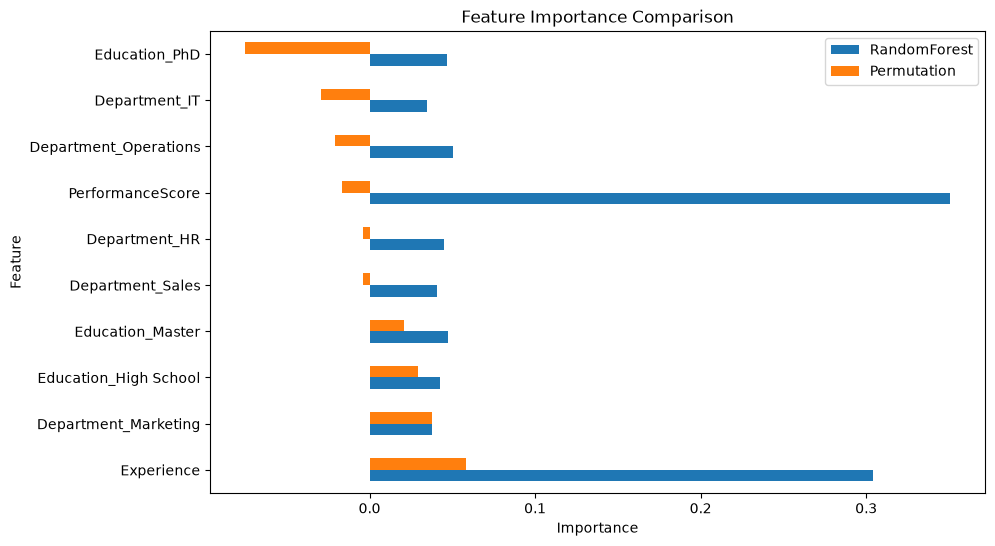

In [3]:
# ====================================
# Import
# ====================================
from pathlib import Path
import pandas as pd

from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# ====================================
# Random Forest Creation
# ====================================
def build_random_forest(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = RandomForestClassifier()

    model.fit(
        X_train,
        y_train
    )

    return model, X_test, y_test

def permutation(model, X_test, y_test):
    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42  
    )

    return result

# ====================================
# Load
# ====================================

BASE_DIR = Path.cwd()

ini_file = BASE_DIR / "data" / "employees.csv"

df = pd.read_csv(ini_file)

# ====================================
# Data Cleaning
# ====================================

df["PerformanceScore"] = df["PerformanceScore"].fillna(
    df["PerformanceScore"].mode()[0]
)
df["Education"] = df["Education"].fillna(
    df["Education"].mode()[0]
)

# ====================================
# Feature Selection
# ====================================

X = df[[
    "PerformanceScore",
    "Education",
    "Department",
    "Experience"
]]


# ====================================
# Target
# ====================================

df["HighSalary"] = (
    df["Salary"] >= df["Salary"].median()
)

y = df["HighSalary"]

# ====================================
# Encoding
# ====================================

X = pd.get_dummies(
    X,
    drop_first=True
)

model, X_test, y_test = build_random_forest(X, y)

result = permutation(
    model,
    X_test,
    y_test
)

print(result.importances_mean)

forest_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "RandomForest": model.feature_importances_
})

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Permutation": result.importances_mean
})

comparison = forest_importance.merge(
    permutation_df,
    on="Feature"
)

comparison = comparison.sort_values(
    by="Permutation",
    ascending=False
)

import matplotlib.pyplot as plt

comparison.plot(
    x="Feature",
    y=["RandomForest", "Permutation"],
    kind="barh",
    figsize=(10,6)
)

plt.title(
    "Feature Importance Comparison"
)

plt.xlabel(
    "Importance"
)

plt.show()

